In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("../../data/processed/opensky/opensky_processed.csv")

print(df.shape)

display(df.head())

(7516, 16)


,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,squawk,spi,position_source
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,119.59,5.20,9829.80,3112.0,False,0
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,12.96,0.33,487.68,NaN,False,0
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,291.13,0.00,10683.24,NaN,False,0
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,165.34,0.65,670.56,NaN,False,0
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,327.49,0.00,11155.68,NaN,False,0


# OpenSky Feature Engineering

The purpose of feature engineering is to transform raw ADS-B observations into operationally meaningful variables that better represent aircraft behaviour.

Rather than relying solely on the original measurements, engineered features describe flight phase, aircraft movement, operational conditions, and potential risk indicators. These features will later serve as inputs to the Gaussian Mixture Model (GMM), Extreme Learning Machine (ELM) Autoencoder, and the Hybrid Aviation Risk Assessment Engine.

In [ ]:
def determine_flight_phase(row):

    if row["on_ground"]:
        return "Ground"

    elif row["vertical_rate"] > 1:
        return "Climb"

    elif row["vertical_rate"] < -1:
        return "Descent"

    else:
        return "Cruise"


df["flight_phase"] = df.apply(determine_flight_phase, axis=1)

display(df["flight_phase"].value_counts())

flight_phase
Cruise     4016
Descent    1739
Climb      1064
Ground      697
Name: count, dtype: int64

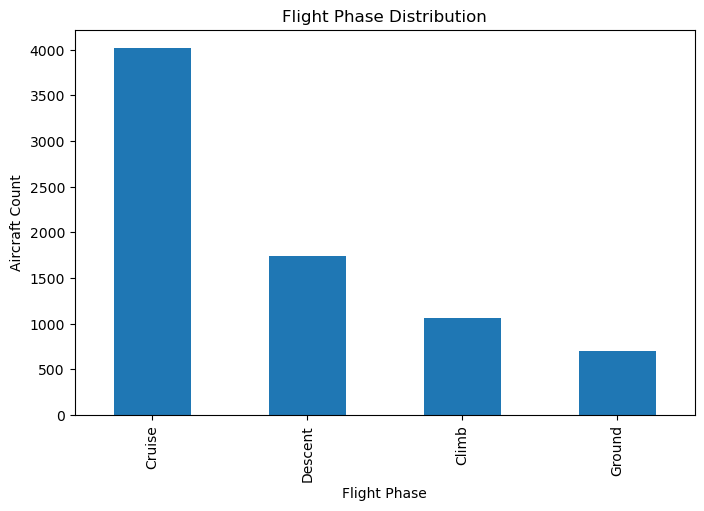

In [6]:
plt.figure(figsize=(8,5))

df["flight_phase"].value_counts().plot(kind="bar")

plt.title("Flight Phase Distribution")

plt.xlabel("Flight Phase")

plt.ylabel("Aircraft Count")

plt.show()

## 2. Speed Category Feature

Aircraft velocity is transformed into operational speed categories. Rather than using raw velocity values alone, categorising aircraft by speed provides operational context that is easier to interpret and supports anomaly detection.

In [ ]:
def speed_category(speed):

    if speed < 15:
        return "Ground / Taxi"

    elif speed < 80:
        return "Low Speed"

    elif speed < 180:
        return "Approach / Departure"

    else:
        return "Cruise Speed"


df["speed_category"] = df["velocity"].apply(speed_category)

display(df["speed_category"].value_counts())

speed_category
Cruise Speed            3852
Approach / Departure    1548
Low Speed               1400
Ground / Taxi            716
Name: count, dtype: int64

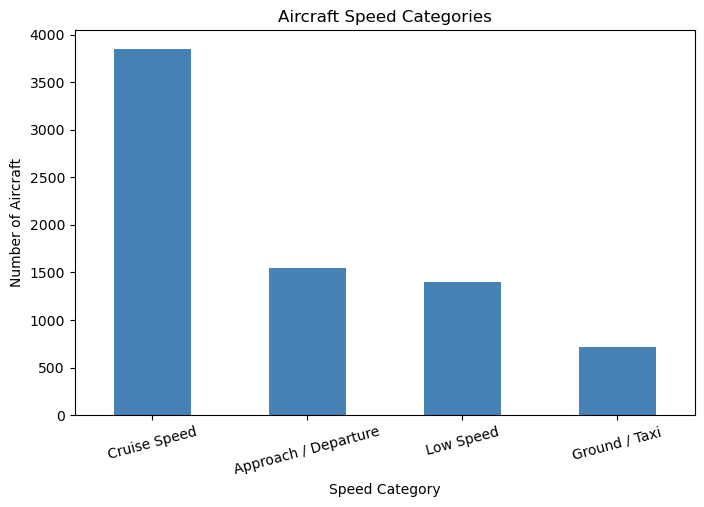

In [ ]:
plt.figure(figsize=(8,5))

df["speed_category"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Aircraft Speed Categories")

plt.xlabel("Speed Category")

plt.ylabel("Number of Aircraft")

plt.xticks(rotation=15)

plt.show()

In [ ]:
def altitude_band(altitude):

    if altitude < 1000:
        return "Low Altitude"

    elif altitude < 5000:
        return "Medium Altitude"

    elif altitude < 10000:
        return "High Altitude"

    else:
        return "Cruise Altitude"


df["altitude_band"] = df["baro_altitude"].apply(altitude_band)

display(df["altitude_band"].value_counts())

altitude_band
Cruise Altitude    2536
High Altitude      2304
Medium Altitude    1587
Low Altitude       1089
Name: count, dtype: int64

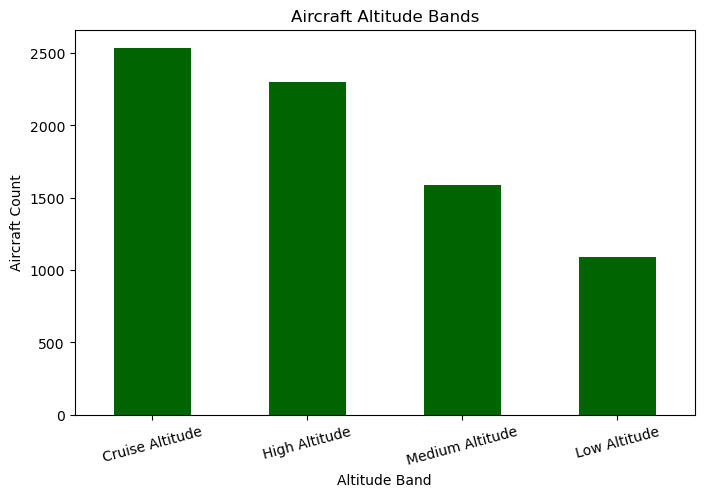

In [ ]:
plt.figure(figsize=(8,5))

df["altitude_band"].value_counts().plot(
    kind="bar",
    color="darkgreen"
)

plt.title("Aircraft Altitude Bands")

plt.xlabel("Altitude Band")

plt.ylabel("Aircraft Count")

plt.xticks(rotation=15)

plt.show()

In [ ]:
def vertical_movement(rate):

    if rate > 1:
        return "Climbing"

    elif rate < -1:
        return "Descending"

    else:
        return "Level Flight"


df["vertical_movement"] = df["vertical_rate"].apply(vertical_movement)

display(df["vertical_movement"].value_counts())

vertical_movement
Level Flight    4712
Descending      1740
Climbing        1064
Name: count, dtype: int64

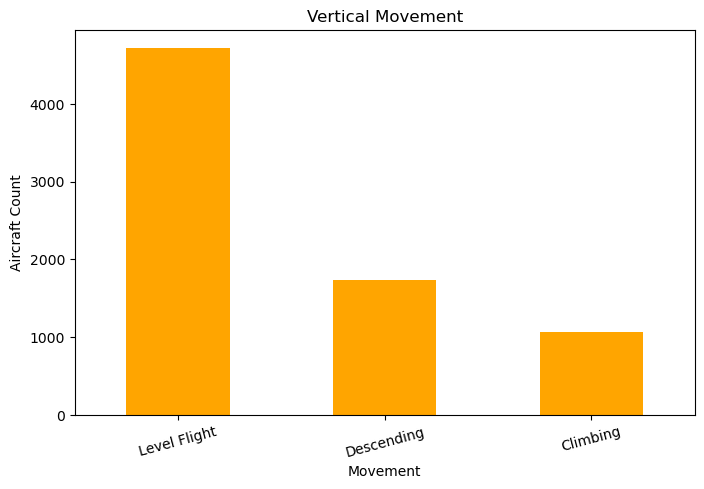

In [12]:
plt.figure(figsize=(8,5))

df["vertical_movement"].value_counts().plot(
    kind="bar",
    color="orange"
)

plt.title("Vertical Movement")

plt.xlabel("Movement")

plt.ylabel("Aircraft Count")

plt.xticks(rotation=15)

plt.show()

In [ ]:
def heading_direction(track):

    if (track >= 315) or (track < 45):
        return "North"

    elif track < 135:
        return "East"

    elif track < 225:
        return "South"

    else:
        return "West"


df["heading_direction"] = df["true_track"].apply(heading_direction)

display(df["heading_direction"].value_counts())

heading_direction
West     2309
East     2003
North    1653
South    1551
Name: count, dtype: int64

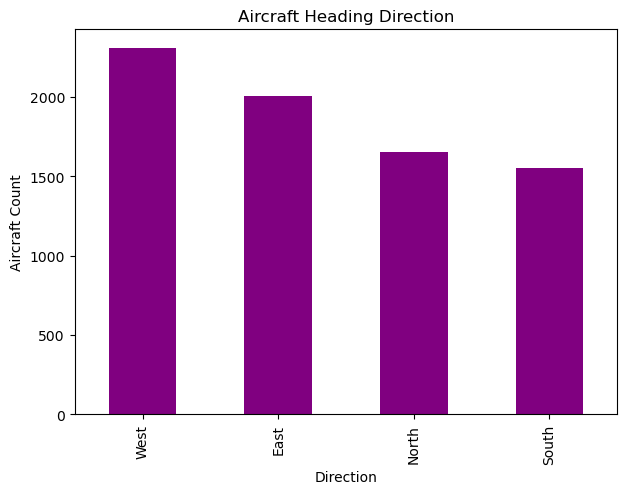

In [14]:
plt.figure(figsize=(7,5))

df["heading_direction"].value_counts().plot(
    kind="bar",
    color="purple"
)

plt.title("Aircraft Heading Direction")

plt.xlabel("Direction")

plt.ylabel("Aircraft Count")

plt.show()

In [ ]:
def operational_risk(row):

    if (
        row["velocity"] > 300
        and abs(row["vertical_rate"]) > 10
    ):
        return "High"

    elif (
        row["velocity"] > 200
        and abs(row["vertical_rate"]) > 5
    ):
        return "Medium"

    else:
        return "Low"


df["operational_risk"] = df.apply(
    operational_risk,
    axis=1
)

display(df["operational_risk"].value_counts())

operational_risk
Low       6974
Medium     542
Name: count, dtype: int64

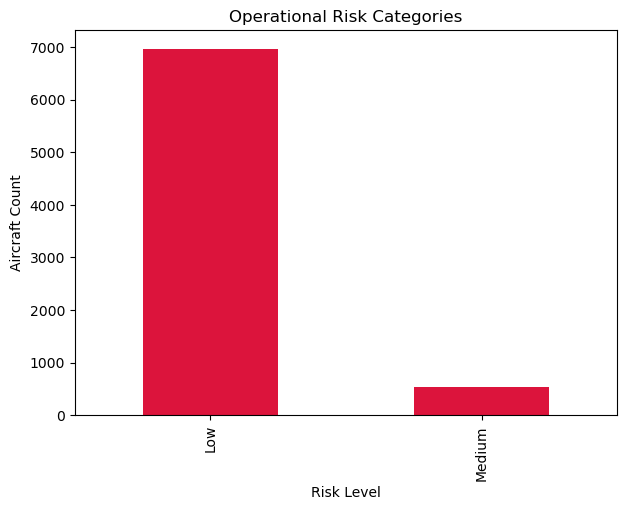

In [16]:
plt.figure(figsize=(7,5))

df["operational_risk"].value_counts().plot(
    kind="bar",
    color="crimson"
)

plt.title("Operational Risk Categories")

plt.xlabel("Risk Level")

plt.ylabel("Aircraft Count")

plt.show()

In [17]:
gmm_features = [
    "latitude",
    "longitude",
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "true_track",
    "vertical_rate"
]

In [18]:
elm_features = [
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "true_track",
    "vertical_rate"
]

In [19]:
hybrid_features = [
    "flight_phase",
    "speed_category",
    "altitude_band",
    "vertical_movement",
    "heading_direction",
    "operational_risk"
]

In [ ]:
df.to_csv(
    "../data/processed/opensky_feature_engineered.csv",
    index=False
)

print(" Feature-engineered OpenSky dataset saved successfully.")
print("Location: data/processed/opensky_feature_engineered.csv")

✅ Feature-engineered OpenSky dataset saved successfully.
Location: data/processed/opensky_feature_engineered.csv
